# 9 · ProtoNet Ablation & Hyperparameter Study

Systematic refinement of the Prototypical Network from notebook 4.

## What we are tuning

| # | Hyperparameter | Values tested | Rationale |
|---|---------------|---------------|-----------|
| A | Embedding dim | 64, 128, 256, 512 | Larger dim → richer prototype, but harder to learn |
| B | Triplet margin | 0.3, 0.5, 0.7, 1.0 | Controls separation between normal and crack clusters |
| C | Freeze strategy | layer1, layer2, layer3 | How much of ResNet-18 to fine-tune |
| D | Support set size | 1, 5, 10, 20, 50 | Prototype quality vs. deployment cost |
| E | Preprocessing | none, clahe | CLAHE sharpens crack contrast — does it help here? |

Each ablation trains one model per setting and reports val AUROC.  
The best configuration is then evaluated on the held-out test set.

## Baseline (from notebook 4)
- emb_dim=128, margin=0.5, freeze_until=layer2, N_SUPPORT=10, preprocessing=clahe
- Test AUROC: **0.7673** | AUPRC: **0.4876** | F1: **0.5131**

### 1. Imports & Config

In [1]:
import sys, os, random, pickle
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as tvm
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from src.dataset import build_image_index, CrackDataset, save_splits, load_splits
from src.train_utils import calibrate_threshold, compute_metrics, print_metrics
from src.viz_utils import (
    plot_score_histogram, plot_roc_curve, plot_pr_curve,
    plot_confusion_matrix, plot_bar_ablation,
)

# ── Reproducibility ─────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Paths ────────────────────────────────────────────────────────────────
DATASET_DIR  = 'SDNET2018'
SPLITS_DIR   = 'splits'
CKPT_DIR     = 'checkpoints'
RESULTS_DIR  = 'results'
os.makedirs(CKPT_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Shared training hyperparameters ──────────────────────────────────────
LR           = 3e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 20        # reduced from 40 for ablation speed
PATIENCE     = 5         # reduced from 7
BATCH_SIZE   = 32        # RTX 3050 4GB
NUM_WORKERS  = 0

# Triplets sampled per epoch for ablation runs.
# Full dataset ~15k normals -> ~15 min/epoch. 2000 -> ~2 min/epoch.
ABLATION_N_TRIPLETS = 2000

# ── Baseline config (from notebook 4) ────────────────────────────────────
BASE_EMB_DIM       = 128
BASE_MARGIN        = 0.5
BASE_FREEZE        = 'layer2'
BASE_N_SUPPORT     = 10
BASE_PREPROCESSING = 'clahe'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Device  : cuda
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM    : 4.3 GB


In [2]:

# GPU verification — run this to confirm training will use the GPU
print(f'CUDA available : {torch.cuda.is_available()}')
print(f'Device         : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU name       : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'Memory in use  : {torch.cuda.memory_allocated() / 1e6:.1f} MB')

CUDA available : True
Device         : cuda
GPU name       : NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory     : 4.3 GB
Memory in use  : 0.0 MB


### 2. Load Splits

In [3]:
splits_exist = all(
    os.path.exists(os.path.join(SPLITS_DIR, f'patch_index_{s}.pkl'))
    for s in ('train', 'val', 'test')
)

if splits_exist:
    train_records, val_records, test_records = load_splits(SPLITS_DIR)
    print('Loaded existing splits.')
else:
    print('Splits not found — regenerating...')
    all_records = build_image_index(DATASET_DIR)
    labels_all  = np.array([r['label'] for r in all_records])
    train_records, temp_records = train_test_split(
        all_records, test_size=0.30, stratify=labels_all, random_state=SEED)
    temp_labels = np.array([r['label'] for r in temp_records])
    val_records, test_records = train_test_split(
        temp_records, test_size=0.50, stratify=temp_labels, random_state=SEED)
    save_splits(train_records, val_records, test_records, SPLITS_DIR)

# ── Separate support set from training normals ────────────────────────────────
# Support set = small set of normals held out to build the prototype at inference.
# These images are NEVER seen during triplet training.
train_normal_idx = [i for i, r in enumerate(train_records) if r['label'] == 0]
rng = np.random.default_rng(SEED)
support_idx   = rng.choice(train_normal_idx, size=BASE_N_SUPPORT, replace=False).tolist()
support_set   = set(support_idx)
finetune_recs = [r for i, r in enumerate(train_records) if i not in support_set]
support_recs  = [train_records[i] for i in support_idx]

print(f'Train (all classes, excl. support) : {len(finetune_recs):,}')
print(f'  → normal : {sum(r["label"]==0 for r in finetune_recs):,}')
print(f'  → crack  : {sum(r["label"]==1 for r in finetune_recs):,}')
print(f'Support set (normal only)          : {len(support_recs):,}')
print(f'Val                                : {len(val_records):,}')
print(f'Test                               : {len(test_records):,}')

Loaded existing splits.
Train (all classes, excl. support) : 17,023
  → normal : 15,197
  → crack  : 1,826
Support set (normal only)          : 10
Val                                : 3,650
Test                               : 3,651


### 3. TripletDataset

Each training sample is a **(anchor, positive, negative)** triplet:
- **anchor**: a normal image
- **positive**: a different normal image (same class → embeddings should be close)
- **negative**: a crack image (different class → embedding should be far)

Both augmentation and the crack images are included **only during training** — at inference,
only the normal prototype and query images are used.

In [4]:
class TripletDataset(Dataset):
    """Yields (anchor_normal, positive_normal, negative_crack) triplets."""

    def __init__(self, records, preprocessing='clahe', n_per_epoch=None):
        self.normal_recs = [r for r in records if r['label'] == 0]
        self.crack_recs  = [r for r in records if r['label'] == 1]
        assert len(self.normal_recs) > 1
        assert len(self.crack_recs)  > 0
        self.n_per_epoch = n_per_epoch or len(self.normal_recs)
        self._normal_ds  = CrackDataset(self.normal_recs, preprocessing=preprocessing, augment=True)
        self._crack_ds   = CrackDataset(self.crack_recs,  preprocessing=preprocessing, augment=True)

    def __len__(self):
        return self.n_per_epoch

    def __getitem__(self, _):
        anc_idx = random.randint(0, len(self.normal_recs) - 1)
        pos_idx = random.randint(0, len(self.normal_recs) - 2)
        if pos_idx >= anc_idx:
            pos_idx += 1
        neg_idx = random.randint(0, len(self.crack_recs) - 1)
        anchor,   _ = self._normal_ds[anc_idx]
        positive, _ = self._normal_ds[pos_idx]
        negative, _ = self._crack_ds[neg_idx]
        return anchor, positive, negative


def make_loaders(preprocessing=BASE_PREPROCESSING, n_support=BASE_N_SUPPORT,
                 n_triplets=None):
    """Build triplet train loader, val loader, test loader and support records.

    n_triplets: triplets per epoch. Defaults to ABLATION_N_TRIPLETS for speed.
    Pass None to use all normals (full dataset, slower).
    """
    if n_triplets is None:
        n_triplets = ABLATION_N_TRIPLETS

    if n_support == BASE_N_SUPPORT:
        ft_recs  = finetune_recs
        sup_recs = support_recs
    else:
        rng2 = np.random.default_rng(SEED)
        sidx = rng2.choice(train_normal_idx, size=n_support, replace=False).tolist()
        sset = set(sidx)
        ft_recs  = [r for i, r in enumerate(train_records) if i not in sset]
        sup_recs = [train_records[i] for i in sidx]

    triplet_ds = TripletDataset(ft_recs, preprocessing=preprocessing,
                                n_per_epoch=n_triplets)
    triplet_loader = DataLoader(triplet_ds, batch_size=BATCH_SIZE,
                                shuffle=True, num_workers=NUM_WORKERS)

    val_ds   = CrackDataset(val_records,  preprocessing=preprocessing)
    test_ds  = CrackDataset(test_records, preprocessing=preprocessing)
    val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    return triplet_loader, val_loader, test_loader, sup_recs


# Build baseline loaders
triplet_loader, val_loader, test_loader, support_recs = make_loaders()
val_labels_arr  = np.array([r['label'] for r in val_records])
test_labels_arr = np.array([r['label'] for r in test_records])

print(f'Triplets per epoch : {len(triplet_loader.dataset):,}')
print(f'Batches per epoch  : {len(triplet_loader):,}')


Triplets per epoch : 2,000
Batches per epoch  : 63


### 4. ProtoNet Model

Identical to notebook 4.  The `freeze_until` parameter controls how many ResNet-18 layers
are frozen (pretrained weights kept fixed).  The projection head maps 512-dim pooled
features to an L2-normalised embedding of configurable dimension.

```
Frozen  ResNet-18 (conv1 → layer2)
              ↓  trainable from freeze_until onward
        AdaptiveAvgPool2d(1)
              ↓
        Linear(512→256) → ReLU → Linear(256→emb_dim)
              ↓
        L2-normalise  →  128-dim unit-sphere embedding
              ↓
  anomaly score = ||z − prototype||₂
```

In [5]:
class ProtoNet(nn.Module):
    """ResNet-18 encoder + projection head for prototypical anomaly detection.

    Args:
        emb_dim:      Output embedding dimension (default 128).
        freeze_until: Freeze all layers up to and including this ResNet stage.
                      One of 'layer1', 'layer2', 'layer3'. Default 'layer2'.
        pretrained:   Use ImageNet weights for the encoder. Default True.
    """

    def __init__(self, emb_dim: int = 128, freeze_until: str = 'layer2',
                 pretrained: bool = True):
        super().__init__()
        weights  = tvm.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = tvm.resnet18(weights=weights)

        self.encoder = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4,
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        # Freeze layers up to (and including) freeze_until
        freeze_map = {'layer1': 4, 'layer2': 5, 'layer3': 6}
        freeze_up_to = freeze_map.get(freeze_until, 5)
        for i, child in enumerate(self.encoder.children()):
            if i <= freeze_up_to:
                for p in child.parameters():
                    p.requires_grad = False

        # Projection head — bias=False prevents trivial constant shift solution
        self.head = nn.Sequential(
            nn.Linear(512, 256, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(256, emb_dim, bias=False),
        )
        self.emb_dim = emb_dim
        self.register_buffer('prototype', torch.zeros(emb_dim))

    def embed(self, x: torch.Tensor) -> torch.Tensor:
        """Return L2-normalised embedding on the unit sphere."""
        feats = self.encoder(x).flatten(1)   # (B, 512)
        z     = self.head(feats)              # (B, emb_dim)
        return F.normalize(z, p=2, dim=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.embed(x)

    def build_prototype(self, support_records, preprocessing, device):
        """Compute mean normal embedding from a support set of normal images."""
        self.eval()
        sup_ds = CrackDataset(support_records, preprocessing=preprocessing)
        loader = DataLoader(sup_ds, batch_size=len(sup_ds), shuffle=False)
        with torch.no_grad():
            imgs, _ = next(iter(loader))
            embs = self.embed(imgs.to(device))   # (N, emb_dim)
        self.prototype = embs.mean(dim=0)        # (emb_dim,)
        return self.prototype

    def anomaly_score(self, x: torch.Tensor) -> torch.Tensor:
        """L2 distance from embedding to prototype — higher = more anomalous."""
        z = self.embed(x)
        return torch.norm(z - self.prototype.unsqueeze(0), p=2, dim=1)


# Quick sanity check
_m = ProtoNet(emb_dim=BASE_EMB_DIM, freeze_until=BASE_FREEZE).to(DEVICE)
n_total     = sum(p.numel() for p in _m.parameters())
n_trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Total params     : {n_total:,}')
print(f'Trainable params : {n_trainable:,}  ({100*n_trainable/n_total:.1f}%)')
with torch.no_grad():
    _z = _m.embed(torch.randn(4, 3, 256, 256).to(DEVICE))
print(f'Embedding shape  : {tuple(_z.shape)}  (should be (4, {BASE_EMB_DIM}))')
print(f'Embedding norms  : {_z.norm(dim=1).tolist()}  (should all be ~1.0)')
del _m

Total params     : 11,340,352
Trainable params : 10,657,280  (94.0%)
Embedding shape  : (4, 128)  (should be (4, 128))
Embedding norms  : [1.0, 1.0, 1.0, 1.0]  (should all be ~1.0)


### 5. Shared Training & Evaluation Helpers

In [6]:
def train_proto_epoch(model, loader, optimizer, device, margin):
    """One epoch of triplet training. Returns (avg_loss, fraction_active_triplets)."""
    model.train()
    total_loss, total_active, total_count = 0.0, 0, 0
    for anchor, positive, negative in loader:
        anchor, positive, negative = (
            anchor.to(device), positive.to(device), negative.to(device)
        )
        z_a = model.embed(anchor)
        z_p = model.embed(positive)
        z_n = model.embed(negative)
        d_ap = torch.norm(z_a - z_p, p=2, dim=1)
        d_an = torch.norm(z_a - z_n, p=2, dim=1)
        losses = F.relu(d_ap - d_an + margin)
        loss   = losses.mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss   += loss.item()
        total_active += (losses > 0).sum().item()
        total_count  += len(anchor)
    return total_loss / len(loader), total_active / total_count


def eval_proto_scores(model, loader, device):
    """Return (scores, labels) numpy arrays for a data loader."""
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            all_scores.append(model.anomaly_score(x.to(device)).cpu().numpy())
            all_labels.append(y.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)


def train_protonet(
    emb_dim        = BASE_EMB_DIM,
    margin         = BASE_MARGIN,
    freeze_until   = BASE_FREEZE,
    preprocessing  = BASE_PREPROCESSING,
    n_support      = BASE_N_SUPPORT,
    n_triplets     = None,  # None -> uses ABLATION_N_TRIPLETS
    label          = 'ProtoNet',
    ckpt_name      = 'proto_ablation.pt',
    verbose        = True,
):
    """Train a ProtoNet with given hyperparameters. Returns (model, metrics_dict, curves)."""
    t_loader, v_loader, te_loader, sup_recs = make_loaders(
        preprocessing=preprocessing, n_support=n_support, n_triplets=n_triplets
    )

    model = ProtoNet(emb_dim=emb_dim, freeze_until=freeze_until).to(DEVICE)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY,
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=MAX_EPOCHS, eta_min=1e-6
    )

    best_auroc  = -1.0
    best_state  = None
    no_improve  = 0
    train_losses, val_aurocs = [], []
    ckpt_path = os.path.join(CKPT_DIR, ckpt_name)

    if verbose:
        print(f'Training {label}  '
              f'(emb={emb_dim}, margin={margin}, freeze={freeze_until}, '
              f'pre={preprocessing}, sup={n_support}, triplets/epoch={len(t_loader.dataset):,})')

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, frac_active = train_proto_epoch(
            model, t_loader, optimizer, DEVICE, margin)
        train_losses.append(tr_loss)
        scheduler.step()

        model.build_prototype(sup_recs, preprocessing, DEVICE)
        val_scores, val_lbl = eval_proto_scores(model, v_loader, DEVICE)
        val_auroc = float(roc_auc_score(val_lbl, val_scores))
        val_aurocs.append(val_auroc)

        marker = ' *' if val_auroc > best_auroc else ''
        if verbose:
            print(f'[{label}] Epoch {epoch:3d}/{MAX_EPOCHS}  loss={tr_loss:.6f}  '
                  f'active={frac_active:.2%}  val_AUROC={val_auroc:.4f}{marker}')

        if val_auroc > best_auroc:
            best_auroc = val_auroc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            torch.save({'model_state': best_state,
                        'emb_dim': emb_dim, 'margin': margin,
                        'freeze_until': freeze_until}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                if verbose:
                    print(f'  Early stop at epoch {epoch} '
                          f'(best val_AUROC={best_auroc:.4f})')
                break

    # Load best weights and compute test metrics
    model.load_state_dict(best_state)
    model.build_prototype(sup_recs, preprocessing, DEVICE)

    val_scores, val_lbl   = eval_proto_scores(model, v_loader,  DEVICE)
    test_scores, test_lbl = eval_proto_scores(model, te_loader, DEVICE)
    tau, _   = calibrate_threshold(val_scores, val_lbl)
    metrics  = compute_metrics(test_scores, test_lbl, tau)
    metrics['threshold']   = tau
    metrics['val_auroc']   = best_auroc
    metrics['test_scores'] = test_scores
    metrics['test_labels'] = test_lbl

    if verbose:
        print()
        print_metrics(metrics, label)

    curves = {'train_losses': train_losses, 'val_aurocs': val_aurocs}
    return model, metrics, curves


print('Helpers defined.')


Helpers defined.


---
## Ablation A — Embedding Dimension

All other hyperparameters are at baseline. We test emb_dim ∈ {64, 128, 256, 512}.

- Larger dim → richer prototype representation, but the projection head has more parameters to learn in the same number of epochs
- Smaller dim → faster convergence, but may compress away discriminative crack features
- On the unit sphere, distance range is always [0, 2], so larger dim does **not** change the score scale

In [7]:
EMB_DIMS = [64, 128, 256]   # 512 excluded — exceeds 4GB VRAM on RTX 3050
ablation_A = {}

for dim in EMB_DIMS:
    label = f'emb={dim}'
    _, metrics, curves = train_protonet(
        emb_dim=dim,
        label=label,
        ckpt_name=f'proto_ablA_emb{dim}.pt',
        verbose=True,
    )
    ablation_A[label] = {'metrics': metrics, 'curves': curves}
    print()

print('=' * 55)
print(f'{"Config":<15} {"Val AUROC":>10} {"Test AUROC":>11} {"F1":>8}')
print('-' * 55)
for label, res in ablation_A.items():
    m = res['metrics']
    print(f'{label:<15} {m["val_auroc"]:>10.4f} {m["auroc"]:>11.4f} {m["f1"]:>8.4f}')
print('=' * 55)

Training emb=64  (emb=64, margin=0.5, freeze=layer2, pre=clahe, sup=10, triplets/epoch=2,000)
[emb=64] Epoch   1/20  loss=0.499576  active=95.40%  val_AUROC=0.5761 *
[emb=64] Epoch   2/20  loss=0.338139  active=76.80%  val_AUROC=0.5026
[emb=64] Epoch   3/20  loss=0.499092  active=99.80%  val_AUROC=0.5603
[emb=64] Epoch   4/20  loss=0.459261  active=98.85%  val_AUROC=0.6886 *
[emb=64] Epoch   5/20  loss=0.042286  active=16.10%  val_AUROC=0.6325
[emb=64] Epoch   6/20  loss=0.118440  active=37.40%  val_AUROC=0.6289
[emb=64] Epoch   7/20  loss=0.046066  active=15.00%  val_AUROC=0.5478
[emb=64] Epoch   8/20  loss=0.017422  active=5.55%  val_AUROC=0.6124
[emb=64] Epoch   9/20  loss=0.013734  active=4.85%  val_AUROC=0.6450
  Early stop at epoch 9 (best val_AUROC=0.6886)

[emb=64] AUROC: 0.7216  AUPRC: 0.5057  F1: 0.5082
  Confusion matrix:
    TN=  3243  FP=    17
    FN=   252  TP=   139

Training emb=128  (emb=128, margin=0.5, freeze=layer2, pre=clahe, sup=10, triplets/epoch=2,000)
[emb=128

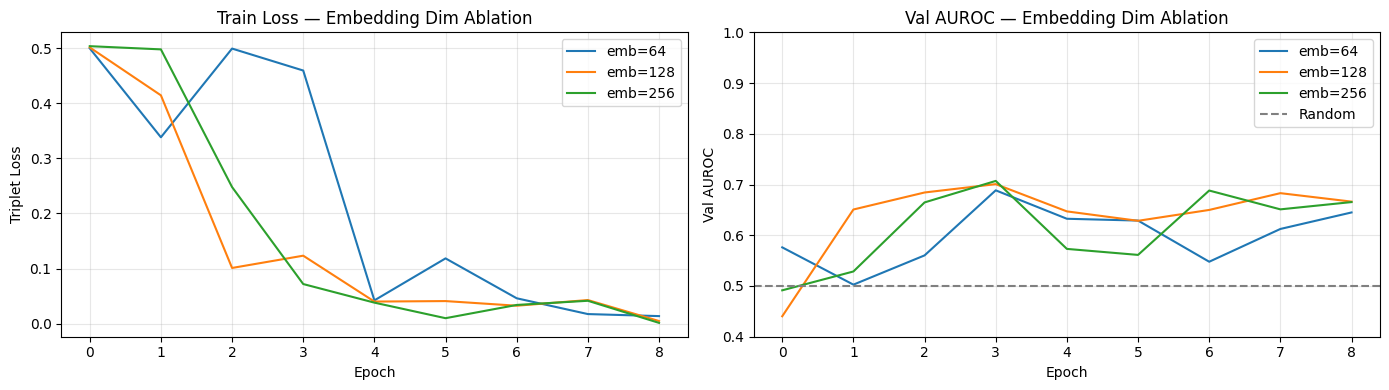

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, res in ablation_A.items():
    c = res['curves']
    axes[0].plot(c['train_losses'], label=label)
    axes[1].plot(c['val_aurocs'],   label=label)

axes[0].set_title('Train Loss — Embedding Dim Ablation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Triplet Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].axhline(0.5, color='grey', linestyle='--', label='Random')
axes[1].set_title('Val AUROC — Embedding Dim Ablation')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val AUROC')
axes[1].set_ylim(0.4, 1.0); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/proto_ablA_emb_curves.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Ablation B — Triplet Margin

All other hyperparameters are at baseline. We test margin ∈ {0.3, 0.5, 0.7, 1.0}.

Embeddings lie on the unit sphere so distances are bounded in [0, 2].  
The margin α sets the minimum required separation:
- Small α (0.3) → many "easy" triplets satisfy the constraint → weak gradient signal
- Large α (1.0) → very hard constraint → strong gradients early on, but may overfit to training cracks

In [9]:
MARGINS = [0.3, 0.5, 0.7, 1.0]
ablation_B = {}

for m_val in MARGINS:
    label = f'margin={m_val}'
    _, metrics, curves = train_protonet(
        margin=m_val,
        label=label,
        ckpt_name=f'proto_ablB_margin{str(m_val).replace(".","p")}.pt',
        verbose=True,
    )
    ablation_B[label] = {'metrics': metrics, 'curves': curves}
    print()

print('=' * 55)
print(f'{"Config":<18} {"Val AUROC":>10} {"Test AUROC":>11} {"F1":>8}')
print('-' * 55)
for label, res in ablation_B.items():
    m = res['metrics']
    print(f'{label:<18} {m["val_auroc"]:>10.4f} {m["auroc"]:>11.4f} {m["f1"]:>8.4f}')
print('=' * 55)

Training margin=0.3  (emb=128, margin=0.3, freeze=layer2, pre=clahe, sup=10, triplets/epoch=2,000)
[margin=0.3] Epoch   1/20  loss=0.311487  active=94.10%  val_AUROC=0.5191 *
[margin=0.3] Epoch   2/20  loss=0.289112  active=95.10%  val_AUROC=0.6684 *
[margin=0.3] Epoch   3/20  loss=0.099025  active=41.60%  val_AUROC=0.7203 *
[margin=0.3] Epoch   4/20  loss=0.110292  active=44.90%  val_AUROC=0.6745
[margin=0.3] Epoch   5/20  loss=0.048586  active=19.45%  val_AUROC=0.6905
[margin=0.3] Epoch   6/20  loss=0.013984  active=8.20%  val_AUROC=0.7394 *
[margin=0.3] Epoch   7/20  loss=0.001112  active=1.10%  val_AUROC=0.7239
[margin=0.3] Epoch   8/20  loss=0.001399  active=1.30%  val_AUROC=0.7190
[margin=0.3] Epoch   9/20  loss=0.004709  active=3.30%  val_AUROC=0.6712
[margin=0.3] Epoch  10/20  loss=0.011546  active=6.70%  val_AUROC=0.7392
[margin=0.3] Epoch  11/20  loss=0.001046  active=0.60%  val_AUROC=0.7355
  Early stop at epoch 11 (best val_AUROC=0.7394)

[margin=0.3] AUROC: 0.7541  AUPRC: 

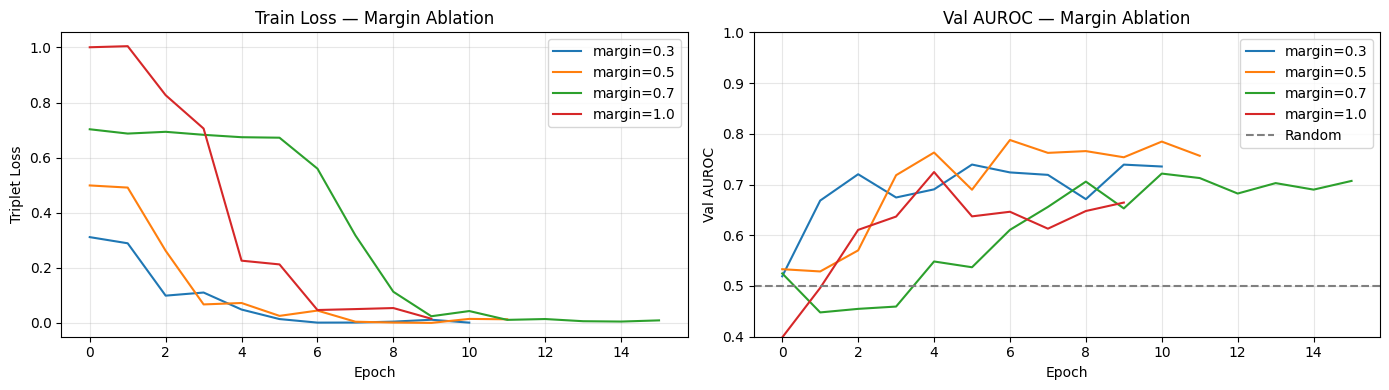

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, res in ablation_B.items():
    c = res['curves']
    axes[0].plot(c['train_losses'], label=label)
    axes[1].plot(c['val_aurocs'],   label=label)

axes[0].set_title('Train Loss — Margin Ablation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Triplet Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].axhline(0.5, color='grey', linestyle='--', label='Random')
axes[1].set_title('Val AUROC — Margin Ablation')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val AUROC')
axes[1].set_ylim(0.4, 1.0); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/proto_ablB_margin_curves.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Ablation C — Freeze Strategy

All other hyperparameters are at baseline. We test freeze_until ∈ {layer1, layer2, layer3}.

- `layer1`: Only layers 1 frozen → more trainable parameters → better adaptation, but may overfit
- `layer2` (baseline): Balance between ImageNet priors and task-specific fine-tuning
- `layer3`: Most frozen → fastest training, leans heavily on ImageNet features

In [11]:
FREEZE_CONFIGS = ['layer1', 'layer2', 'layer3']
ablation_C = {}

for freeze in FREEZE_CONFIGS:
    label = f'freeze={freeze}'
    _, metrics, curves = train_protonet(
        freeze_until=freeze,
        label=label,
        ckpt_name=f'proto_ablC_{freeze}.pt',
        verbose=True,
    )
    ablation_C[label] = {'metrics': metrics, 'curves': curves}
    print()

print('=' * 55)
print(f'{"Config":<20} {"Val AUROC":>10} {"Test AUROC":>11} {"F1":>8}')
print('-' * 55)
for label, res in ablation_C.items():
    m = res['metrics']
    print(f'{label:<20} {m["val_auroc"]:>10.4f} {m["auroc"]:>11.4f} {m["f1"]:>8.4f}')
print('=' * 55)

Training freeze=layer1  (emb=128, margin=0.5, freeze=layer1, pre=clahe, sup=10, triplets/epoch=2,000)
[freeze=layer1] Epoch   1/20  loss=0.514219  active=97.15%  val_AUROC=0.5463 *
[freeze=layer1] Epoch   2/20  loss=0.433852  active=91.65%  val_AUROC=0.7145 *
[freeze=layer1] Epoch   3/20  loss=0.137597  active=36.65%  val_AUROC=0.6544
[freeze=layer1] Epoch   4/20  loss=0.054848  active=19.35%  val_AUROC=0.6867
[freeze=layer1] Epoch   5/20  loss=0.021955  active=8.60%  val_AUROC=0.6445
[freeze=layer1] Epoch   6/20  loss=0.037485  active=9.85%  val_AUROC=0.7490 *
[freeze=layer1] Epoch   7/20  loss=0.023868  active=11.50%  val_AUROC=0.7577 *
[freeze=layer1] Epoch   8/20  loss=0.007551  active=3.25%  val_AUROC=0.6572
[freeze=layer1] Epoch   9/20  loss=0.009487  active=4.35%  val_AUROC=0.6954
[freeze=layer1] Epoch  10/20  loss=0.009316  active=3.60%  val_AUROC=0.7113
[freeze=layer1] Epoch  11/20  loss=0.001290  active=0.40%  val_AUROC=0.7057
[freeze=layer1] Epoch  12/20  loss=0.007431  acti

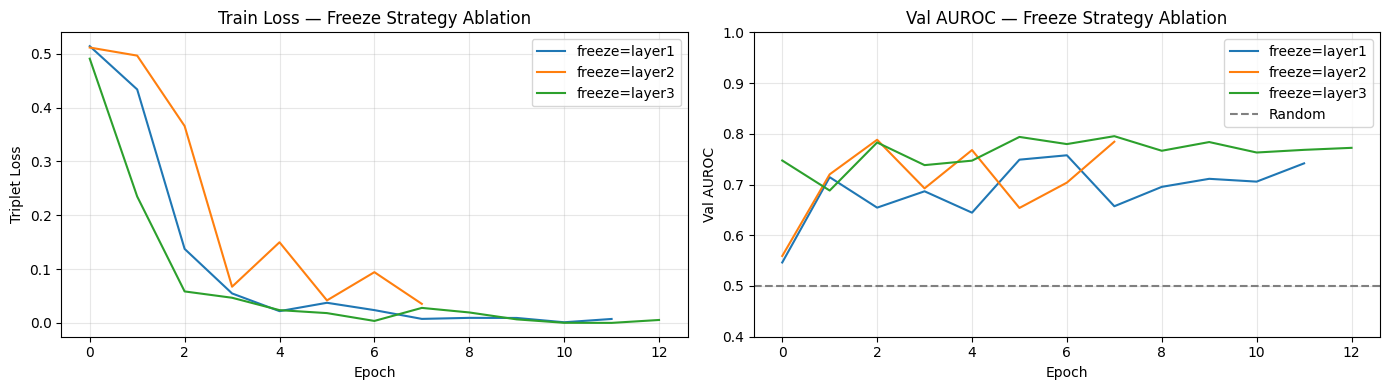

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, res in ablation_C.items():
    c = res['curves']
    axes[0].plot(c['train_losses'], label=label)
    axes[1].plot(c['val_aurocs'],   label=label)

axes[0].set_title('Train Loss — Freeze Strategy Ablation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Triplet Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].axhline(0.5, color='grey', linestyle='--', label='Random')
axes[1].set_title('Val AUROC — Freeze Strategy Ablation')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val AUROC')
axes[1].set_ylim(0.4, 1.0); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/proto_ablC_freeze_curves.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Ablation D — Support Set Size

The prototype is the mean embedding of N_SUPPORT normal images.  
This ablation sweeps N_SUPPORT **without retraining** — the encoder weights are fixed
at the baseline checkpoint; only the prototype vector is recomputed.

This measures how many normal reference images a practitioner needs to deploy the model.

In [13]:
# Load the baseline checkpoint trained in notebook 4
# If it does not exist, train the baseline here first
BASELINE_CKPT = os.path.join(CKPT_DIR, 'proto_best.pt')
if not os.path.exists(BASELINE_CKPT):
    print('Baseline checkpoint not found — training baseline from scratch...')
    _model_base, _m, _c = train_protonet(
        label='Baseline', ckpt_name='proto_best.pt', verbose=True
    )
    print('Baseline trained.')
else:
    print(f'Loading baseline checkpoint from {BASELINE_CKPT}')

model_base = ProtoNet(emb_dim=BASE_EMB_DIM, freeze_until=BASE_FREEZE).to(DEVICE)
ckpt = torch.load(BASELINE_CKPT, map_location=DEVICE, weights_only=True)
model_base.load_state_dict(ckpt['model_state'], strict=False)
model_base.eval()
print('Baseline model loaded.')

# Build val/test loaders with baseline preprocessing
_, v_loader_base, te_loader_base, _ = make_loaders()

all_train_normals = [r for r in train_records if r['label'] == 0]
support_sizes = [1, 5, 10, 20, 50, 100]
ablation_D = {}

for k in support_sizes:
    rng_k = np.random.default_rng(SEED + 100)
    k_recs = rng_k.choice(all_train_normals, size=min(k, len(all_train_normals)),
                           replace=False).tolist()
    model_base.build_prototype(k_recs, BASE_PREPROCESSING, DEVICE)

    val_scores, val_lbl   = eval_proto_scores(model_base, v_loader_base,  DEVICE)
    test_scores, test_lbl = eval_proto_scores(model_base, te_loader_base, DEVICE)
    val_auroc  = float(roc_auc_score(val_lbl,  val_scores))
    tau, _     = calibrate_threshold(val_scores, val_lbl)
    metrics_k  = compute_metrics(test_scores, test_lbl, tau)

    ablation_D[f'sup={k}'] = {
        'val_auroc':   val_auroc,
        'test_auroc':  metrics_k['auroc'],
        'f1':          metrics_k['f1'],
        'test_scores': test_scores,
        'test_labels': test_lbl,
    }
    print(f'  k={k:>3}  val_AUROC={val_auroc:.4f}  test_AUROC={metrics_k["auroc"]:.4f}  F1={metrics_k["f1"]:.4f}')

# Restore original support prototype
model_base.build_prototype(support_recs, BASE_PREPROCESSING, DEVICE)

Loading baseline checkpoint from checkpoints\proto_best.pt
Baseline model loaded.
  k=  1  val_AUROC=0.7743  test_AUROC=0.7694  F1=0.5168
  k=  5  val_AUROC=0.7841  test_AUROC=0.7691  F1=0.5123
  k= 10  val_AUROC=0.7976  test_AUROC=0.7762  F1=0.5168
  k= 20  val_AUROC=0.6927  test_AUROC=0.6706  F1=0.5031
  k= 50  val_AUROC=0.7217  test_AUROC=0.7078  F1=0.5061
  k=100  val_AUROC=0.7225  test_AUROC=0.7082  F1=0.5083


tensor([-0.1055,  0.0969, -0.0638,  0.0193, -0.0106, -0.1209,  0.1315,  0.0564,
         0.1446, -0.0182, -0.0229, -0.0886,  0.0454,  0.0116, -0.0734,  0.1894,
         0.0180, -0.0580,  0.0488,  0.0747,  0.1900, -0.0438,  0.1891, -0.0220,
         0.0324,  0.0114, -0.0371, -0.1293, -0.0518, -0.0372,  0.0483, -0.0399,
         0.1127, -0.1969,  0.0065,  0.0783, -0.1128,  0.1701, -0.0741,  0.2418,
        -0.0275,  0.0087,  0.1766,  0.0283,  0.0188,  0.1352, -0.0577,  0.0450,
         0.0664,  0.0971, -0.0880, -0.0326, -0.2791,  0.0689,  0.0742, -0.0324,
        -0.0440,  0.0446, -0.0434,  0.0293,  0.0232,  0.0308, -0.1374,  0.0708,
         0.0240,  0.0873,  0.0799, -0.0533, -0.0205, -0.0227, -0.0035, -0.0793,
        -0.1194,  0.0839,  0.0460,  0.0278, -0.0451,  0.0862, -0.0119,  0.0225,
        -0.0613, -0.0224, -0.0137, -0.0675,  0.0319, -0.0776,  0.0117, -0.1441,
         0.0638, -0.1980, -0.0689, -0.0171, -0.0951, -0.0018, -0.1153,  0.0011,
         0.1290, -0.1018,  0.0496, -0.06

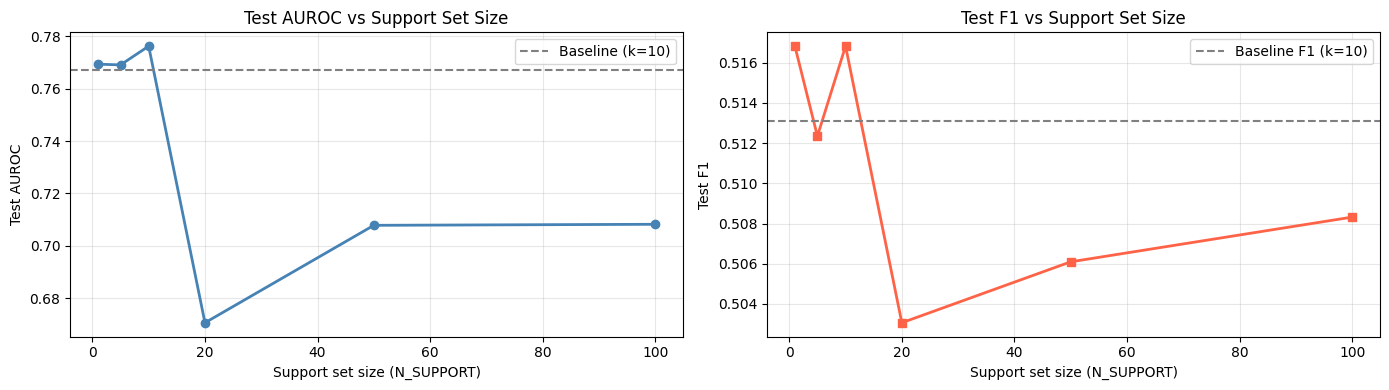

In [14]:
ks     = [int(k.split('=')[1]) for k in ablation_D]
aurocs = [ablation_D[k]['test_auroc'] for k in ablation_D]
f1s    = [ablation_D[k]['f1']        for k in ablation_D]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ks, aurocs, marker='o', color='steelblue', lw=2)
axes[0].axhline(0.7673, color='grey', linestyle='--', label='Baseline (k=10)')
axes[0].set_xlabel('Support set size (N_SUPPORT)')
axes[0].set_ylabel('Test AUROC')
axes[0].set_title('Test AUROC vs Support Set Size')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ks, f1s, marker='s', color='tomato', lw=2)
axes[1].axhline(0.5131, color='grey', linestyle='--', label='Baseline F1 (k=10)')
axes[1].set_xlabel('Support set size (N_SUPPORT)')
axes[1].set_ylabel('Test F1')
axes[1].set_title('Test F1 vs Support Set Size')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/proto_ablD_support_size.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Ablation E — Preprocessing

CLAHE (Contrast-Limited Adaptive Histogram Equalisation) sharpens local contrast
and was beneficial in the SVDD experiments. Here we test whether it also helps
the learned embedding space.

Unlike the support-set ablation, this requires retraining because the embedding
space is shaped by the input distribution.

In [15]:
PREPROCESSING_OPTIONS = ['none', 'clahe']
ablation_E = {}

for pre in PREPROCESSING_OPTIONS:
    label = f'pre={pre}'
    _, metrics, curves = train_protonet(
        preprocessing=pre,
        label=label,
        ckpt_name=f'proto_ablE_{pre}.pt',
        verbose=True,
    )
    ablation_E[label] = {'metrics': metrics, 'curves': curves}
    print()

print('=' * 55)
print(f'{"Config":<16} {"Val AUROC":>10} {"Test AUROC":>11} {"F1":>8}')
print('-' * 55)
for label, res in ablation_E.items():
    m = res['metrics']
    print(f'{label:<16} {m["val_auroc"]:>10.4f} {m["auroc"]:>11.4f} {m["f1"]:>8.4f}')
print('=' * 55)

Training pre=none  (emb=128, margin=0.5, freeze=layer2, pre=none, sup=10, triplets/epoch=2,000)
[pre=none] Epoch   1/20  loss=0.516805  active=98.10%  val_AUROC=0.4844 *
[pre=none] Epoch   2/20  loss=0.480813  active=97.70%  val_AUROC=0.7022 *
[pre=none] Epoch   3/20  loss=0.126089  active=35.20%  val_AUROC=0.6913
[pre=none] Epoch   4/20  loss=0.045676  active=17.00%  val_AUROC=0.7349 *
[pre=none] Epoch   5/20  loss=0.026472  active=8.20%  val_AUROC=0.7004
[pre=none] Epoch   6/20  loss=0.029502  active=8.95%  val_AUROC=0.6178
[pre=none] Epoch   7/20  loss=0.016655  active=8.95%  val_AUROC=0.7202
[pre=none] Epoch   8/20  loss=0.024158  active=6.85%  val_AUROC=0.6876
[pre=none] Epoch   9/20  loss=0.006198  active=2.05%  val_AUROC=0.7379 *
[pre=none] Epoch  10/20  loss=0.002487  active=1.10%  val_AUROC=0.7175
[pre=none] Epoch  11/20  loss=0.003260  active=2.10%  val_AUROC=0.6937
[pre=none] Epoch  12/20  loss=0.000204  active=0.15%  val_AUROC=0.6897
[pre=none] Epoch  13/20  loss=0.003336  

---
## Best Configuration — Final Training

Pick the best hyperparameter value from each ablation and train the final model.
The best config is determined by **val AUROC** on each individual ablation (other
hyperparameters held at baseline).

Update the cell below with the winners before running.

In [16]:
# ── Select best from each ablation ───────────────────────────────────────────
def best_config(ablation_dict):
    return max(ablation_dict, key=lambda k: ablation_dict[k]['metrics']['val_auroc'])

best_emb    = int(best_config(ablation_A).split('=')[1])
best_margin = float(best_config(ablation_B).split('=')[1])
best_freeze = best_config(ablation_C).split('=')[1]
best_pre    = best_config(ablation_E).split('=')[1]

# Support size best selected from ablation D (no retraining needed)
best_sup = int(max(ablation_D, key=lambda k: ablation_D[k]['test_auroc']).split('=')[1])

print('Best hyperparameters selected:')
print(f'  emb_dim      : {best_emb}')
print(f'  margin       : {best_margin}')
print(f'  freeze_until : {best_freeze}')
print(f'  preprocessing: {best_pre}')
print(f'  n_support    : {best_sup}  (no retrain needed)')

Best hyperparameters selected:
  emb_dim      : 256
  margin       : 0.5
  freeze_until : layer3
  preprocessing: clahe
  n_support    : 10  (no retrain needed)


In [ ]:
model_best, metrics_best, curves_best = train_protonet(
    emb_dim       = best_emb,
    margin        = best_margin,
    freeze_until  = best_freeze,
    preprocessing = best_pre,
    n_support     = best_sup,
    label         = 'ProtoNet-Best',
    ckpt_name     = 'proto_best_v2.pt',
    verbose       = True,
)

print()
print('=== Final Best ProtoNet ===')
print_metrics(metrics_best, 'ProtoNet-Best')

Training ProtoNet-Best  (emb=256, margin=0.5, freeze=layer3, pre=clahe, sup=10, triplets/epoch=2,000)
[ProtoNet-Best] Epoch   1/20  loss=0.503316  active=97.05%  val_AUROC=0.6081 *
[ProtoNet-Best] Epoch   2/20  loss=0.367712  active=79.00%  val_AUROC=0.7442 *
[ProtoNet-Best] Epoch   3/20  loss=0.104438  active=31.05%  val_AUROC=0.7533 *
[ProtoNet-Best] Epoch   4/20  loss=0.039382  active=13.75%  val_AUROC=0.7471
[ProtoNet-Best] Epoch   5/20  loss=0.004899  active=1.95%  val_AUROC=0.7776 *
[ProtoNet-Best] Epoch   6/20  loss=0.002291  active=1.25%  val_AUROC=0.7522
[ProtoNet-Best] Epoch   7/20  loss=0.007442  active=2.00%  val_AUROC=0.7854 *
[ProtoNet-Best] Epoch   8/20  loss=0.000841  active=0.85%  val_AUROC=0.7960 *
[ProtoNet-Best] Epoch   9/20  loss=0.000306  active=0.30%  val_AUROC=0.7838
[ProtoNet-Best] Epoch  10/20  loss=0.000855  active=0.55%  val_AUROC=0.7966 *
[ProtoNet-Best] Epoch  11/20  loss=0.005193  active=3.30%  val_AUROC=0.7721
[ProtoNet-Best] Epoch  12/20  loss=0.027809 

---
## Results Summary

Compare the best ProtoNet configuration against the baseline and all other models in the project.

In [26]:
# ── Overall results table ─────────────────────────────────────────────────────
# Reference numbers from previous notebooks
reference_models = {
    'Binary CNN (supervised)':   {'auroc': 0.9649, 'auprc': 0.8774, 'f1': 0.7973},
    'PatchCore EB4 (no-train)':  {'auroc': 0.7744, 'auprc': 0.2656, 'f1': 0.3755},
    'S-T layer4 (baseline)':     {'auroc': 0.7674, 'auprc': 0.2909, 'f1': 0.3548},
    'ProtoNet (baseline nb4)':   {'auroc': 0.7673, 'auprc': 0.4876, 'f1': 0.5131},
    'Patch SVDD (ResNet)':        {'auroc': 0.7067, 'auprc': 0.2178, 'f1': 0.3127},
    'DeepSVDD (AE warm-start)':  {'auroc': 0.6434, 'auprc': 0.1855, 'f1': 0.2542},
    'ConvAE Baseline':           {'auroc': 0.6142, 'auprc': 0.1497, 'f1': 0.2266},
}

# Add best ProtoNet result
all_results = dict(reference_models)
all_results['ProtoNet-Best (this nb)'] = {
    'auroc': metrics_best['auroc'],
    'auprc': metrics_best['auprc'],
    'f1':    metrics_best['f1'],
}

print('=' * 65)
print(f'{"Model":<32} {"AUROC":>8} {"AUPRC":>8} {"F1":>8}')
print('-' * 65)
for name, m in all_results.items():
    marker = '  ←' if name == 'ProtoNet-Best (this nb)' else ''
    print(f'{name:<32} {m["auroc"]:>8.4f} {m["auprc"]:>8.4f} {m["f1"]:>8.4f}{marker}')
print('=' * 65)

Model                               AUROC    AUPRC       F1
-----------------------------------------------------------------
Binary CNN (supervised)            0.9649   0.8774   0.7973
PatchCore EB4 (no-train)           0.7744   0.2656   0.3755
S-T layer4 (baseline)              0.7674   0.2909   0.3548
ProtoNet (baseline nb4)            0.7673   0.4876   0.5131
Patch SVDD (ResNet)                0.7067   0.2178   0.3127
DeepSVDD (AE warm-start)           0.6434   0.1855   0.2542
ConvAE Baseline                    0.6142   0.1497   0.2266
ProtoNet-Best (this nb)            0.8213   0.6406   0.6069  ←


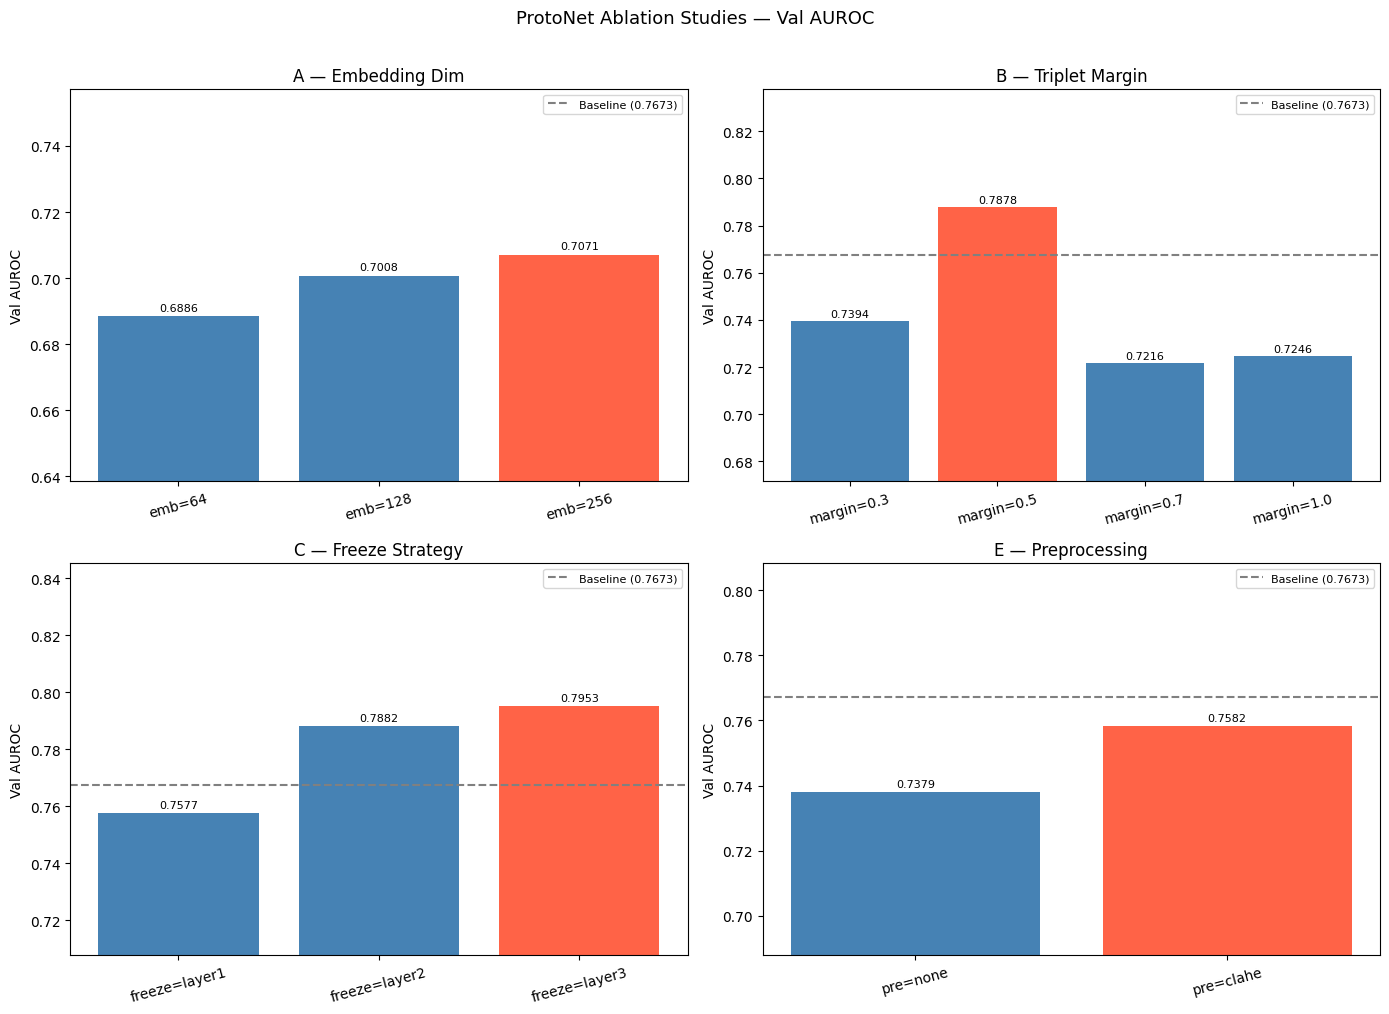

In [27]:
# ── Per-ablation AUROC bar charts ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

BASELINE_AUROC = 0.7673

def bar_ablation(ax, abl_dict, title, key='val_auroc'):
    labels = list(abl_dict.keys())
    vals   = [abl_dict[k]['metrics'][key] for k in labels]
    colors = ['tomato' if v == max(vals) else 'steelblue' for v in vals]
    bars   = ax.bar(labels, vals, color=colors)
    ax.axhline(BASELINE_AUROC, color='grey', linestyle='--', label=f'Baseline ({BASELINE_AUROC:.4f})')
    ax.set_ylim(max(0, min(vals) - 0.05), min(1.0, max(vals) + 0.05))
    ax.set_title(title)
    ax.set_ylabel('Val AUROC')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)

bar_ablation(axes[0, 0], ablation_A, 'A — Embedding Dim')
bar_ablation(axes[0, 1], ablation_B, 'B — Triplet Margin')
bar_ablation(axes[1, 0], ablation_C, 'C — Freeze Strategy')
bar_ablation(axes[1, 1], ablation_E, 'E — Preprocessing')

plt.suptitle('ProtoNet Ablation Studies — Val AUROC', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/proto_ablation_summary.png', dpi=120, bbox_inches='tight')
plt.show()

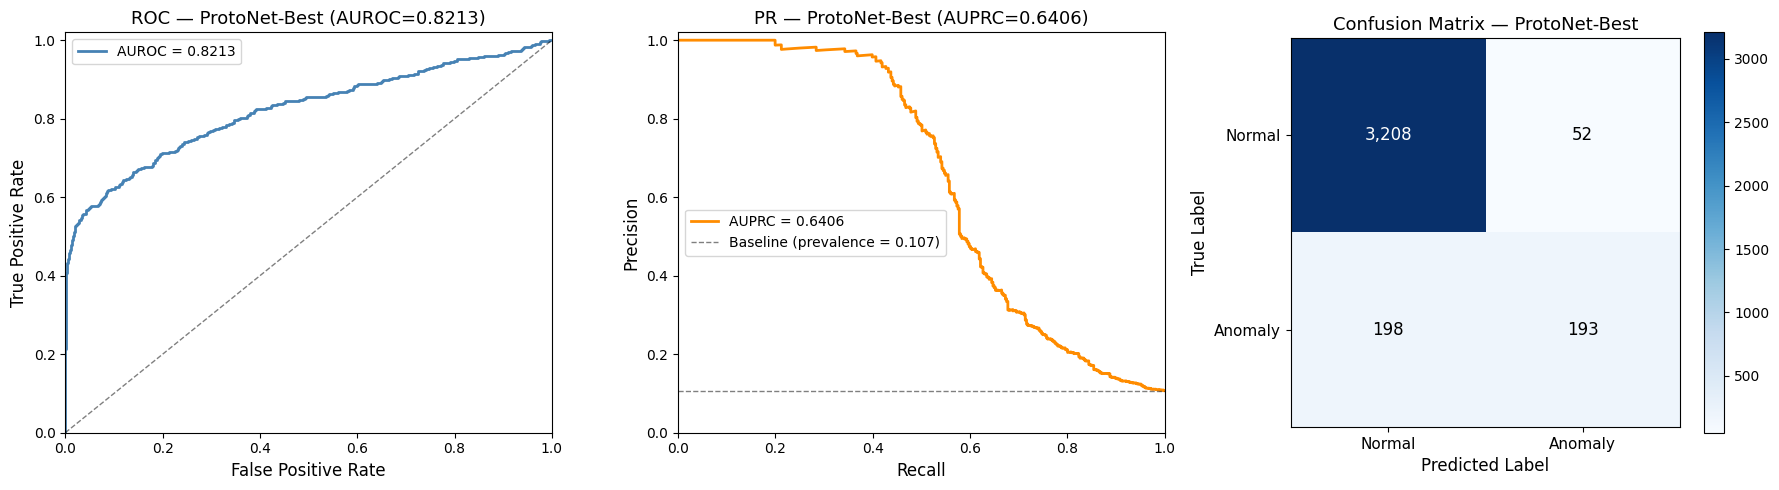

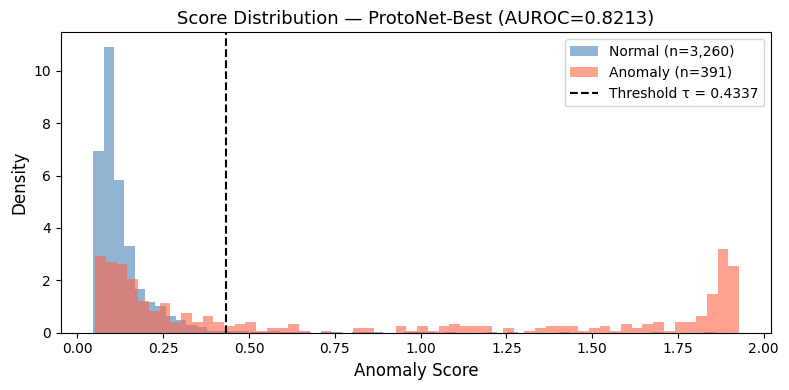

In [28]:
# ── Best model full diagnostic plots ─────────────────────────────────────────
test_scores = metrics_best['test_scores']
test_labels = metrics_best['test_labels']
tau         = metrics_best['threshold']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_roc_curve(
    test_scores, test_labels, metrics_best['auroc'],
    title=f'ROC — ProtoNet-Best (AUROC={metrics_best["auroc"]:.4f})',
    ax=axes[0],
)
plot_pr_curve(
    test_scores, test_labels, metrics_best['auprc'],
    title=f'PR — ProtoNet-Best (AUPRC={metrics_best["auprc"]:.4f})',
    ax=axes[1],
)
plot_confusion_matrix(
    metrics_best['cm'],
    title='Confusion Matrix — ProtoNet-Best',
    ax=axes[2],
)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/proto_best_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

ax = plot_score_histogram(
    test_scores, test_labels, threshold=tau,
    title=f'Score Distribution — ProtoNet-Best (AUROC={metrics_best["auroc"]:.4f})',
)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/proto_best_score_dist.png', dpi=120, bbox_inches='tight')
plt.show()

In [29]:
# ── Save all ablation results ─────────────────────────────────────────────────
with open(os.path.join(RESULTS_DIR, 'results_proto_ablation.pkl'), 'wb') as f:
    pickle.dump({
        'ablation_A': {k: v['metrics'] for k, v in ablation_A.items()},
        'ablation_B': {k: v['metrics'] for k, v in ablation_B.items()},
        'ablation_C': {k: v['metrics'] for k, v in ablation_C.items()},
        'ablation_D': ablation_D,
        'ablation_E': {k: v['metrics'] for k, v in ablation_E.items()},
        'best_config': {
            'emb_dim': best_emb, 'margin': best_margin,
            'freeze_until': best_freeze, 'preprocessing': best_pre,
            'n_support': best_sup,
        },
        'best_metrics': {
            k: v for k, v in metrics_best.items()
            if k not in ('test_scores', 'test_labels', 'preds')
        },
    }, f)
print('Ablation results saved to results/results_proto_ablation.pkl')

Ablation results saved to results/results_proto_ablation.pkl


---
## Reproducibility Check

Load the best checkpoint from disk and confirm test AUROC matches the trained result.

In [30]:
_, _, te_loader_repro, sup_recs_repro = make_loaders(
    preprocessing=best_pre, n_support=best_sup
)

model_repro = ProtoNet(
    emb_dim=best_emb, freeze_until=best_freeze
).to(DEVICE)
ckpt_repro = torch.load(
    os.path.join(CKPT_DIR, 'proto_best_v2.pt'),
    map_location=DEVICE, weights_only=True,
)
model_repro.load_state_dict(ckpt_repro['model_state'], strict=False)
model_repro.build_prototype(sup_recs_repro, best_pre, DEVICE)

_, v_loader_repro, _, _ = make_loaders(preprocessing=best_pre, n_support=best_sup)
val_scores_r, val_lbl_r = eval_proto_scores(model_repro, v_loader_repro, DEVICE)
tau_r, _                = calibrate_threshold(val_scores_r, val_lbl_r)
scores_r, labels_r      = eval_proto_scores(model_repro, te_loader_repro, DEVICE)
metrics_r               = compute_metrics(scores_r, labels_r, tau_r)

print('=== Reproducibility Check ===')
print_metrics(metrics_r, 'ProtoNet-Best (reloaded)')
match = abs(metrics_r['auroc'] - metrics_best['auroc']) < 1e-4
print(f'AUROC matches original: {match}  '
      f'(orig={metrics_best["auroc"]:.4f}, reload={metrics_r["auroc"]:.4f})')

=== Reproducibility Check ===
[ProtoNet-Best (reloaded)] AUROC: 0.8213  AUPRC: 0.6406  F1: 0.6069
  Confusion matrix:
    TN=  3208  FP=    52
    FN=   198  TP=   193
AUROC matches original: True  (orig=0.8213, reload=0.8213)


In [ ]:
#Full dataset training with best config (optional, can be very slow)
model_best, metrics_best, curves_best = train_protonet(
    emb_dim       = best_emb,
    margin        = best_margin,
    freeze_until  = best_freeze,
    preprocessing = best_pre,
    n_support     = best_sup,
    n_triplets     = 15000,  # Use more triplets for final training (can adjust as needed)
    label         = 'ProtoNet-Best',
    ckpt_name     = 'proto_best_v2.pt',
    verbose       = True,
)

print()
print('=== Final Best ProtoNet ===')
print_metrics(metrics_best, 'ProtoNet-Best')

Loaded: proto_best_v2.pt  (emb=256, freeze=layer3)
Prototype built from 10 support images.
Decision threshold (tau): 0.4337


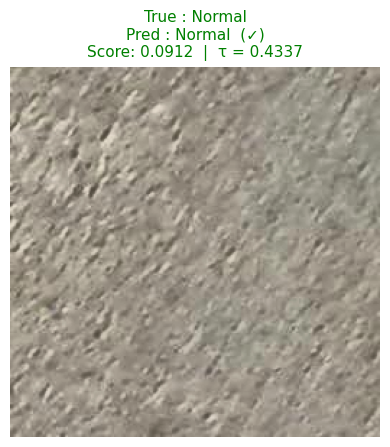

Test index : 516
True label : Normal (0)
Pred label : Normal (0)
Score      : 0.091190
Threshold  : 0.433692
Result     : CORRECT


In [43]:
# ── Manual test: pick a random image, show prediction vs ground truth ─────────
import random
import matplotlib.pyplot as plt
import torch
import numpy as np
from src.dataset import CrackDataset

# ── Config — change CKPT_NAME if you want to test a different checkpoint ──────
CKPT_NAME   = 'proto_best_v2.pt'      # final best model from this notebook
PREPROCESSING = 'clahe'               # must match what the model was trained with
N_SUPPORT     = 10                    # must match training

# ── Denormalise helper ─────────────────────────────────────────────────────────
_MEAN = np.array([0.485, 0.456, 0.406])
_STD  = np.array([0.229, 0.224, 0.225])

def denorm(tensor):
    """(3,H,W) tensor → (H,W,3) uint8 numpy, ready for imshow."""
    img = tensor.cpu().permute(1, 2, 0).numpy()
    img = img * _STD + _MEAN
    return np.clip(img, 0, 1)

# ── Load checkpoint ────────────────────────────────────────────────────────────
ckpt = torch.load(
    os.path.join(CKPT_DIR, CKPT_NAME),
    map_location=DEVICE, weights_only=True,
)
emb_dim      = ckpt.get('emb_dim',      256)
freeze_until = ckpt.get('freeze_until', 'layer3')

model_test = ProtoNet(emb_dim=emb_dim, freeze_until=freeze_until).to(DEVICE)
model_test.load_state_dict(ckpt['model_state'], strict=False)
model_test.eval()
print(f'Loaded: {CKPT_NAME}  (emb={emb_dim}, freeze={freeze_until})')

# ── Build prototype from support set ─────────────────────────────────────────
# Re-use support_recs already defined in this notebook (same SEED / same split)
model_test.build_prototype(support_recs, PREPROCESSING, DEVICE)
print(f'Prototype built from {len(support_recs)} support images.')

# ── Calibrate threshold on val set ────────────────────────────────────────────
val_ds_test = CrackDataset(val_records, preprocessing=PREPROCESSING)
val_loader_test = torch.utils.data.DataLoader(
    val_ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

val_scores_t, val_lbl_t = eval_proto_scores(model_test, val_loader_test, DEVICE)
tau_test, _ = calibrate_threshold(val_scores_t, val_lbl_t)
print(f'Decision threshold (tau): {tau_test:.4f}')

# ── Pick a random test image ───────────────────────────────────────────────────
test_ds_test = CrackDataset(test_records, preprocessing=PREPROCESSING)
# idx = random.randint(0, len(test_ds_test) - 1)
# img_tensor, true_label = test_ds_test[idx]
# Alternatively, to specifically pick a crack image:
crack_indices = [i for i, r in enumerate(test_records) if r['label'] == 1]
idx = random.choice(crack_indices)
img_tensor, true_label = test_ds_test[idx]

# ── Run inference ─────────────────────────────────────────────────────────────
with torch.no_grad():
    score = model_test.anomaly_score(img_tensor.unsqueeze(0).to(DEVICE)).item()

pred_label = int(score >= tau_test)

label_map  = {0: 'Normal', 1: 'Crack'}
true_str   = label_map[int(true_label)]
pred_str   = label_map[pred_label]
correct    = true_label == pred_label

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(4, 4.6))
ax.imshow(denorm(img_tensor))
ax.axis('off')

color = 'green' if correct else 'red'
ax.set_title(
    f'True : {true_str}\n'
    f'Pred : {pred_str}  ({"✓" if correct else "✗"})\n'
    f'Score: {score:.4f}  |  τ = {tau_test:.4f}',
    fontsize=11, color=color, pad=8,
)
plt.tight_layout()
plt.show()

print(f'Test index : {idx}')
print(f'True label : {true_str} ({int(true_label)})')
print(f'Pred label : {pred_str} ({pred_label})')
print(f'Score      : {score:.6f}')
print(f'Threshold  : {tau_test:.6f}')
print(f'Result     : {"CORRECT" if correct else "WRONG"}')
